# Welcome to the INTSYCURE Jupyter Notebook

This will be the primary jupyter notebook for us to do our feature engineering and model training. Kindly follow each section when modifying this notebook to make things easier. Feel free to make subsections if needed.

## README

This code's main branch will be in `mco2`. For creating your own branch, kindly format the branch name with `mco2-<name>` (first name or last name up to you). Branch off from this `mco2` branch, make your changes, and the changes can be later pulled into the main branch or specific features/code can be manaully taken from each of our notebooks, since the jupyter notebook format may be a pain in the azz to work with in git.

## Import Modules

Kindly install these modules if required.

In [12]:
# Installing packages (run in cli):
#   pip install <package name 

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
LABELS = ["ENG", "FIL", "CS", "OTH"]

## Importing the Data
The `master_dataset.csv` file is imported, ready to be used.

In [13]:
data = pd.read_csv("master_dataset.csv")

data = data.dropna(subset=["sentence_id", "word", "annot"]).copy()

data["word"] = data["word"].astype(str)
data["annot"] = data["annot"].astype(str).str.strip().str.upper()

data = data[data["annot"].isin(LABELS)].copy()

print(data.shape)
print(data["annot"].value_counts())

data.head()

(9636, 5)
annot
FIL    7284
OTH    1402
ENG     916
CS       34
Name: count, dtype: int64


,sentence_id,word_id,sentence,word,annot
0,0,0,Kaya kayong mga babae wag kayong basta basta m...,Kaya,FIL
1,0,1,Kaya kayong mga babae wag kayong basta basta m...,kayong,FIL
2,0,2,Kaya kayong mga babae wag kayong basta basta m...,mga,FIL
3,0,3,Kaya kayong mga babae wag kayong basta basta m...,babae,FIL
4,0,4,Kaya kayong mga babae wag kayong basta basta m...,wag,FIL


In [14]:
split1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=RANDOM_STATE
)


train_index, temp_index = next(
    split1.split(data, groups=data["sentence_id"])
)

train_data = data.iloc[train_index]
temp_data = data.iloc[temp_index]

split2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=RANDOM_STATE
)

validation_index, test_index = next(
    split2.split(temp_data, groups=temp_data["sentence_id"])
)

validation_data = temp_data.iloc[validation_index]
test_data = temp_data.iloc[test_index]

X_train = train_data["word"]
y_train = train_data["annot"]
X_validation = validation_data["word"]
y_validation = validation_data["annot"]
X_test = test_data["word"]
y_test = test_data["annot"]

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Train: 6615
Validation: 1586
Test: 1435


In [15]:
def show_split_information(name, dataset):
    print(f"{name}")
    print("-" * 40)
    print("Tokens:", len(dataset))
    print(
        "Sentences:",
        dataset["sentence_id"].nunique()
    )
    print("\nLabel counts:")
    print(
        dataset["annot"]
        .value_counts()
        .reindex(LABELS)
        .fillna(0)
        .astype(int)
    )
    print()


show_split_information("TRAINING SET", train_data)
show_split_information("VALIDATION SET", validation_data)
show_split_information("TEST SET", test_data)

TRAINING SET
----------------------------------------
Tokens: 6615
Sentences: 350

Label counts:
annot
ENG     608
FIL    5033
CS       22
OTH     952
Name: count, dtype: int64

VALIDATION SET
----------------------------------------
Tokens: 1586
Sentences: 75

Label counts:
annot
ENG     173
FIL    1167
CS        7
OTH     239
Name: count, dtype: int64

TEST SET
----------------------------------------
Tokens: 1435
Sentences: 75

Label counts:
annot
ENG     135
FIL    1084
CS        5
OTH     211
Name: count, dtype: int64



## Feature Engineering

In this section, we will engineer each of the features for the model to be trained.

In [21]:
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

feature_options = {
    "Character 1-3": (1, 3),
    "Character 2-4": (2, 4),
    "Character 2-5": (2, 5)
}


## Model Training
This section will contain the main code for training and exporting our model.

In [22]:
results = []
trained_models = {}

for feature_name, ngram_range in feature_options.items():
    for model_name, classifier in models.items():

        pipeline = Pipeline([
            (
                "features",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=ngram_range,
                    lowercase=True
                )
            ),
            (
                "classifier",
                clone(classifier)
            )
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_validation)

        accuracy = accuracy_score(
            y_validation,
            predictions
        )

        macro_f1 = f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        )

        results.append({
            "model": model_name,
            "features": feature_name,
            "accuracy": accuracy,
            "macro_f1": macro_f1
        })

        trained_models[
            (model_name, feature_name)
        ] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

results_df

,model,features,accuracy,macro_f1
0,Logistic Regression,Character 1-3,0.899117,0.666581
1,Linear SVM,Character 1-3,0.926860,0.645582
2,Linear SVM,Character 2-5,0.922446,0.639985
3,Linear SVM,Character 2-4,0.921185,0.638820
4,Logistic Regression,Character 2-5,0.892812,0.613227
5,Logistic Regression,Character 2-4,0.890921,0.612073
6,Naive Bayes,Character 1-3,0.885876,0.582075
7,Naive Bayes,Character 2-4,0.803909,0.430242
8,Naive Bayes,Character 2-5,0.793821,0.404924


In [23]:
best_row = results_df.iloc[0]

best_model_name = best_row["model"]
best_feature_name = best_row["features"]

best_model = trained_models[
    (best_model_name, best_feature_name)
]

test_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Best features:", best_feature_name)

print(
    "Test accuracy:",
    accuracy_score(y_test, test_predictions)
)

print(
    "Test macro F1:",
    f1_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

print(
    classification_report(
        y_test,
        test_predictions,
        labels=LABELS,
        zero_division=0
    )
)


Best model: Logistic Regression
Best features: Character 1-3
Test accuracy: 0.9031358885017422
Test macro F1: 0.6652736675370752
              precision    recall  f1-score   support

         ENG       0.58      0.83      0.68       135
         FIL       0.96      0.94      0.95      1084
          CS       0.20      0.20      0.20         5
         OTH       0.91      0.75      0.82       211

    accuracy                           0.90      1435
   macro avg       0.66      0.68      0.67      1435
weighted avg       0.92      0.90      0.91      1435



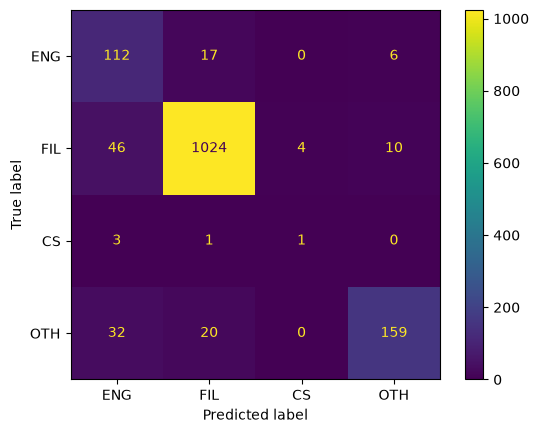

In [24]:
matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=LABELS
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=LABELS
)

display.plot()
plt.show()

In [25]:



final_training_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True
)

X_final_train = final_training_data["word"]
y_final_train = final_training_data["annot"]



final_model = Pipeline([
    (
        "features",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(1, 3),
            lowercase=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])



final_model.fit(
    X_final_train,
    y_final_train
)



sample_tokens = [
    "Love",
    "kita",
    "."
]

print(
    "Test prediction:",
    final_model.predict(sample_tokens).tolist()
)


MODEL_PATH = "trained_model.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("Model saved:", os.path.abspath(MODEL_PATH))
print("File exists:", os.path.exists(MODEL_PATH))

Test prediction: ['ENG', 'FIL', 'OTH']
Model saved: C:\Users\Wesley\Desktop\intsycurities\mco2-pinoybot\trained_model.pkl
File exists: True
